## Гига М.Я. М8О-313Б-23

MSE = 24.99

In [1]:
from typing import List, Tuple, cast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import KBinsDiscretizer, LabelEncoder, OneHotEncoder, StandardScaler, RobustScaler, OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression, VarianceThreshold
from sklearn.model_selection import train_test_split, KFold, cross_val_score
import os
import seaborn as sns
from scipy import stats
import scipy
from scipy.stats import norm, skew
from scipy.special import inv_boxcox
from sklearn.mixture import GaussianMixture
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model

pd.options.display.max_columns = None

import warnings
warnings.filterwarnings("ignore")

In [2]:
def optimal_weight(y, pred_a, pred_b):
    d = pred_a - pred_b
    denom = np.dot(d, d)
    if denom == 0:
        return 0.5
    w = float(np.dot(d, (y - pred_b)) / denom)
    return float(np.clip(w, 0.0, 1.0))

Преобразуем dataframe, убираем nan, убираем некорректные значения

In [3]:
df: pd.DataFrame = pd.read_csv("./data/train.csv")
df = df[~df["RiskScore"].isna()]
df = cast(pd.DataFrame, df[df["RiskScore"].abs() < 200])
df.head()  # pyright: ignore[reportUnusedExpression]

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,RiskScore
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,0.151985,2.0,1.0,0.168542,0.0,Education,0.0,23.0,5.0,2539.0,247.0,50072.0,15005.0,5569.083333,0.908289,4.0,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,66.176500
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,0.175693,3.0,0.0,0.141553,0.0,Home,0.0,27.0,11.0,844.0,694.0,91878.0,64877.0,14345.583333,0.797339,2.0,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,28.495737
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,0.444605,3.0,0.0,0.030987,1.0,Education,0.0,21.0,12.0,12756.0,651.0,292300.0,13918.0,25000.000000,0.915945,3.0,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,34.488104
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,0.188452,7.0,0.0,0.379843,0.0,Debt Consolidation,0.0,27.0,21.0,1524.0,529.0,13070.0,3846.0,2890.250000,0.876416,3.0,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,36.910753
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,0.273431,3.0,1.0,0.068659,0.0,Debt Consolidation,0.0,35.0,9.0,1973.0,128.0,33357.0,351603.0,25000.000000,0.888689,5.0,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,31.347091


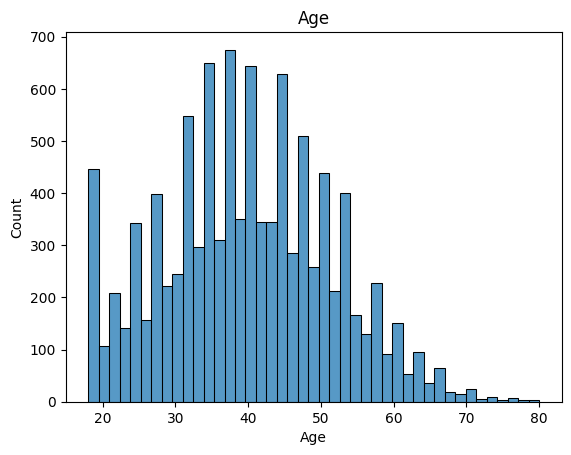

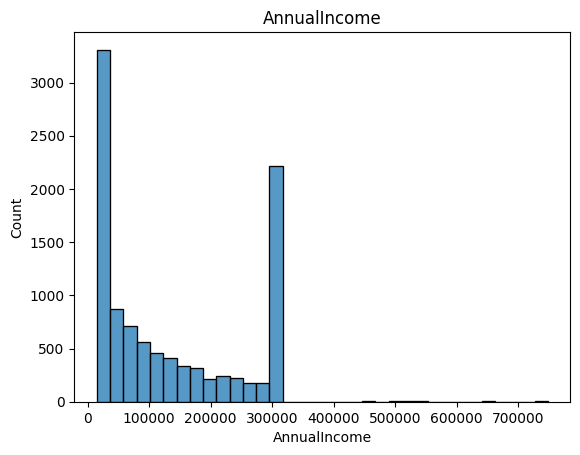

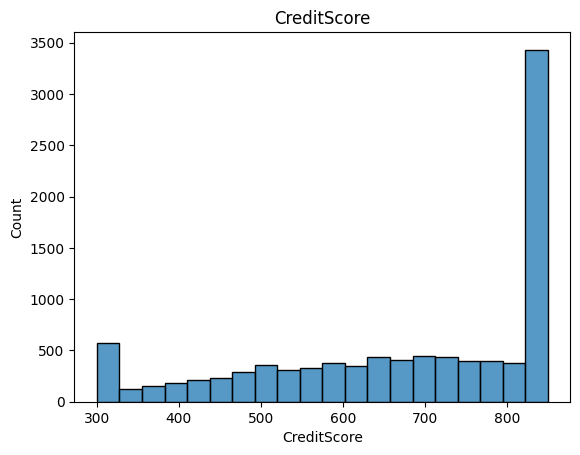

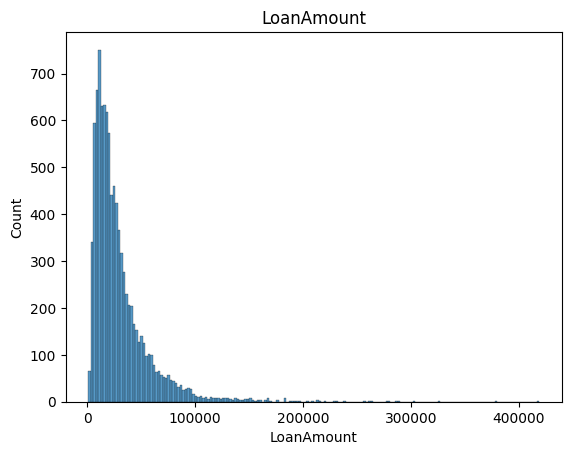

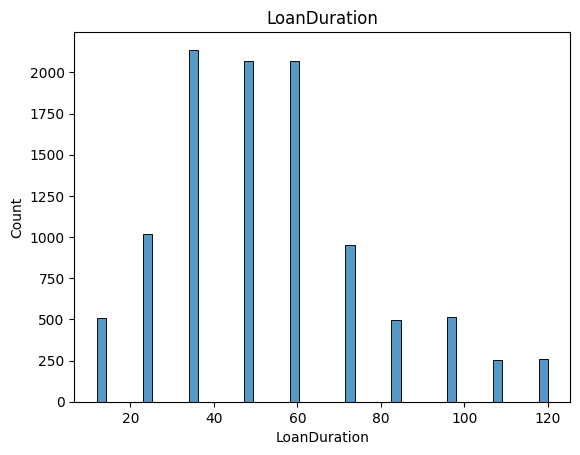

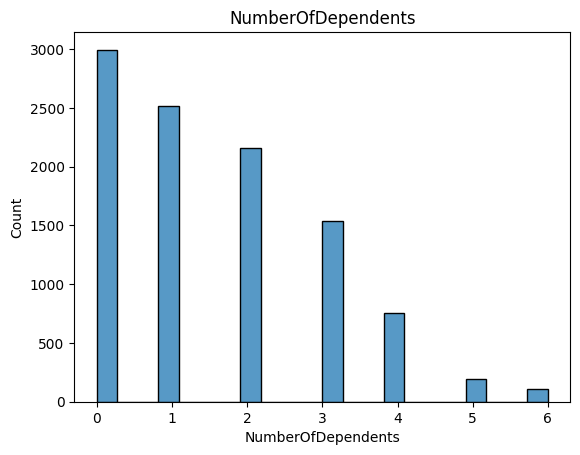

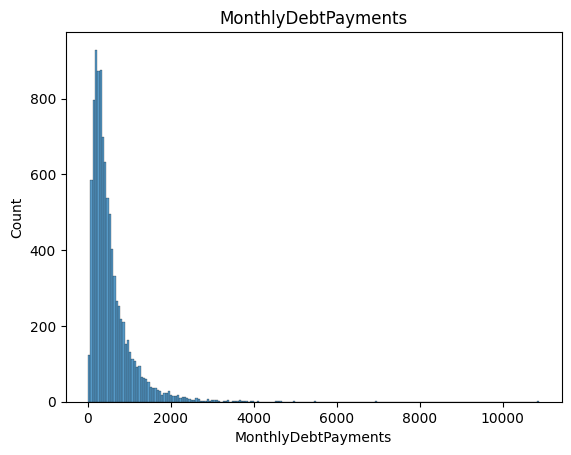

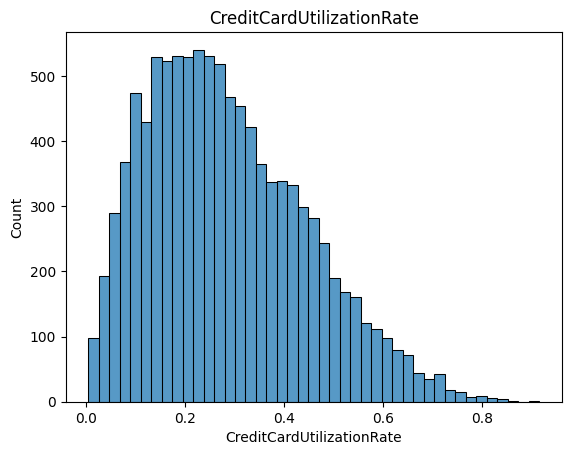

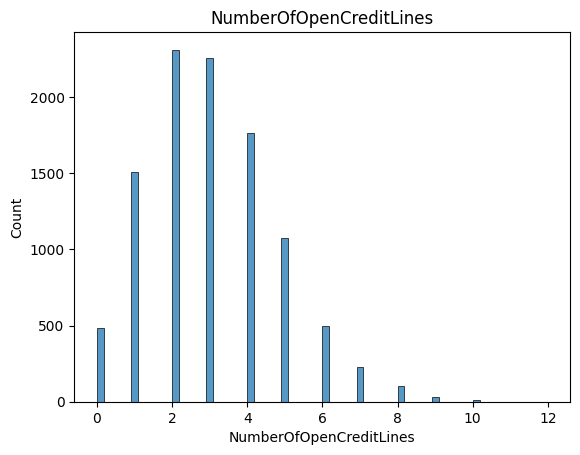

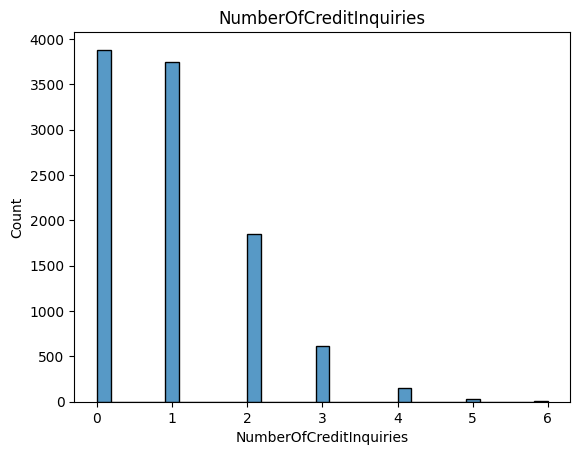

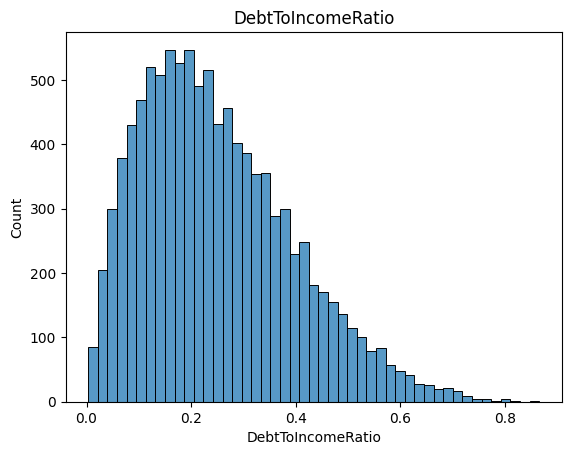

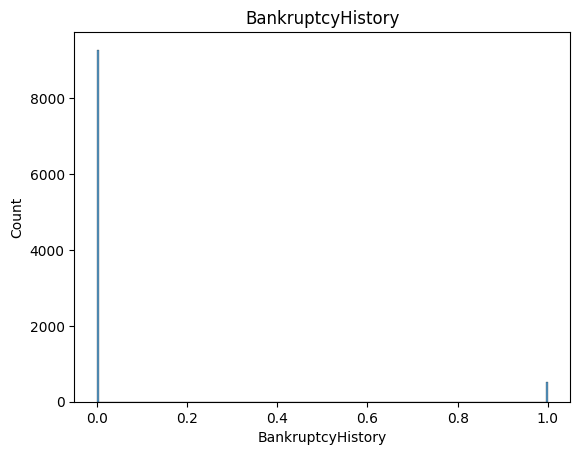

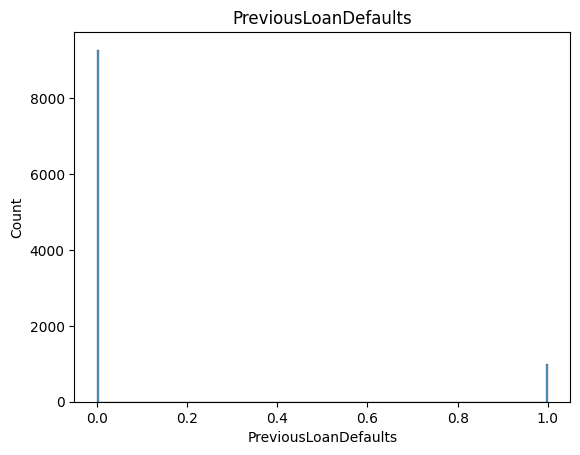

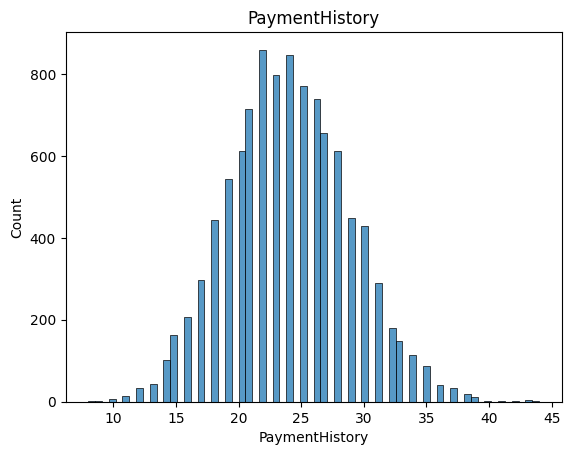

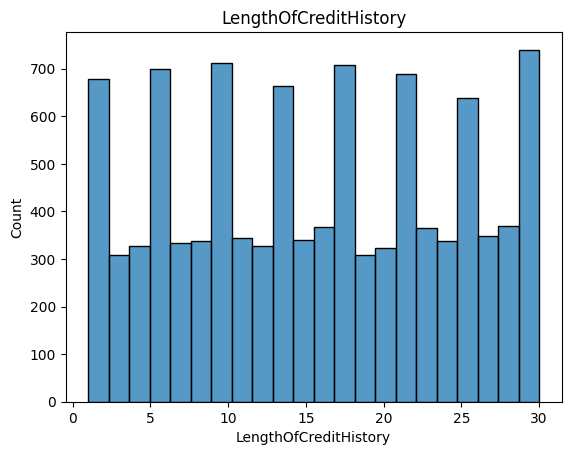

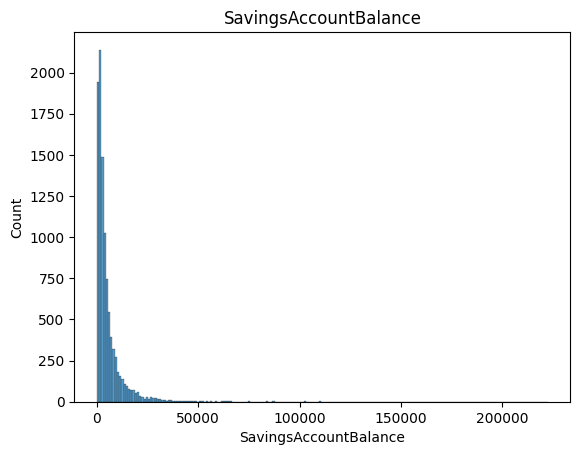

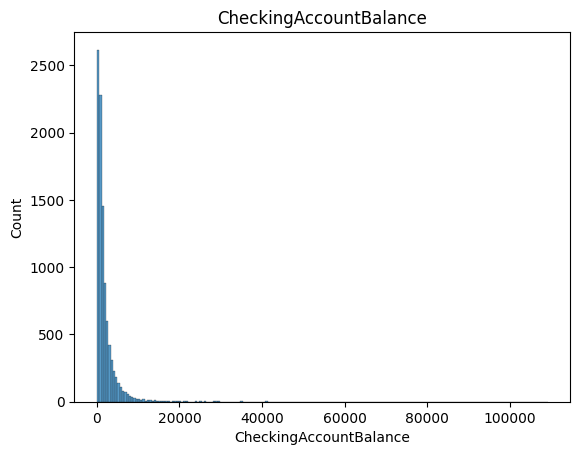

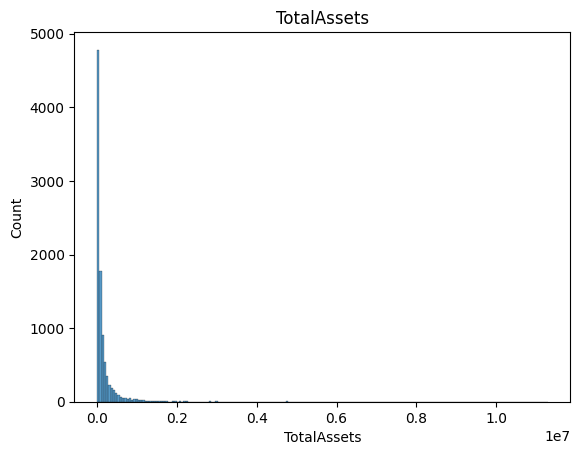

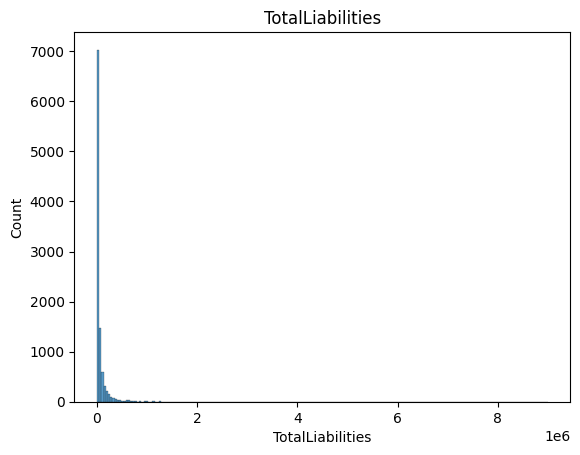

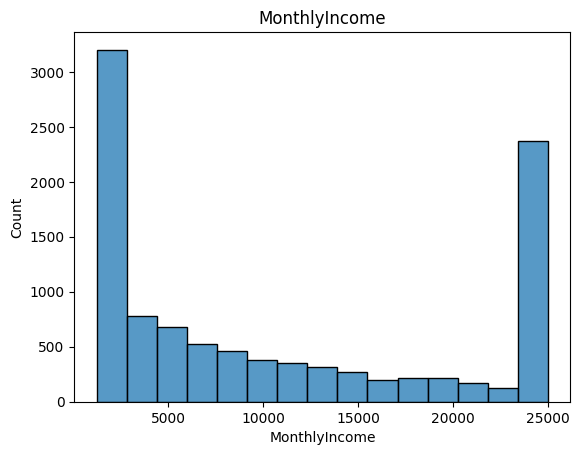

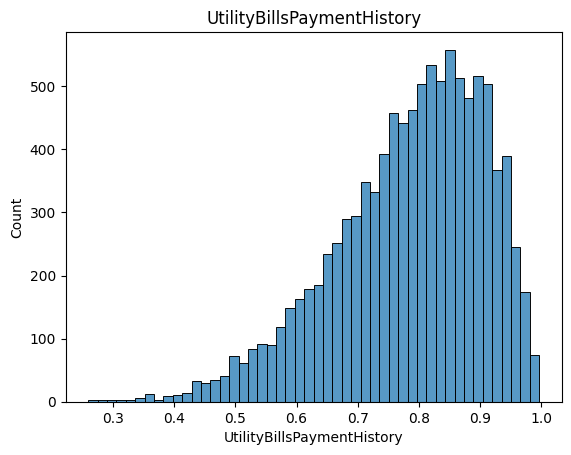

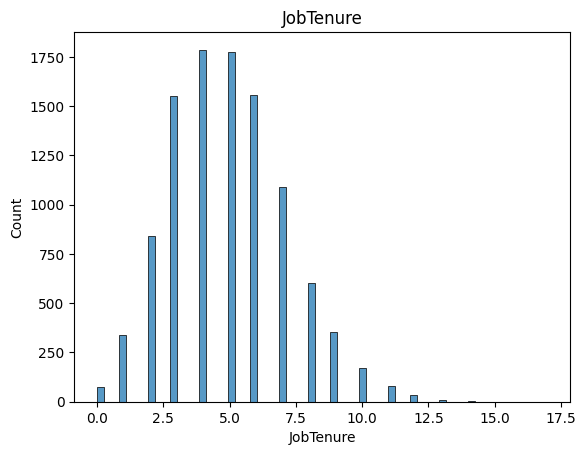

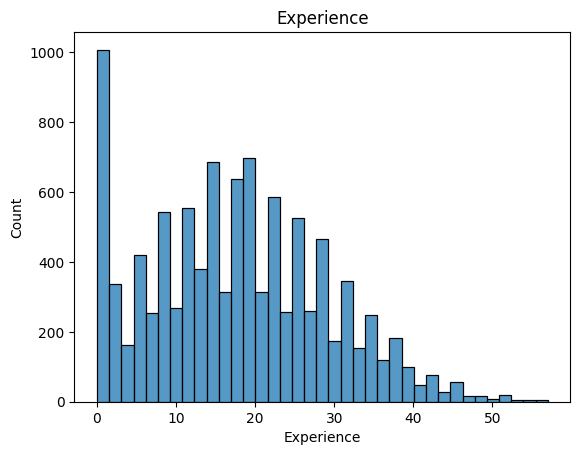

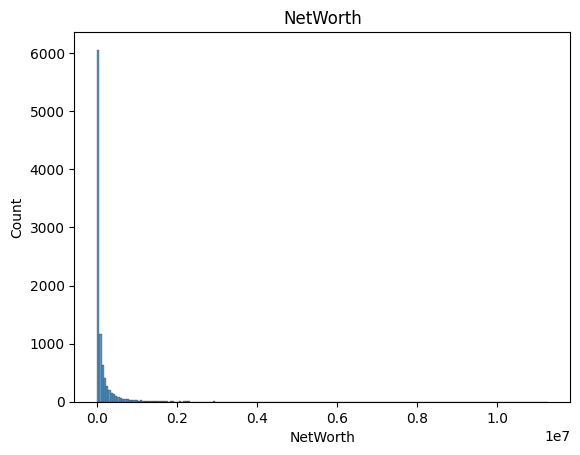

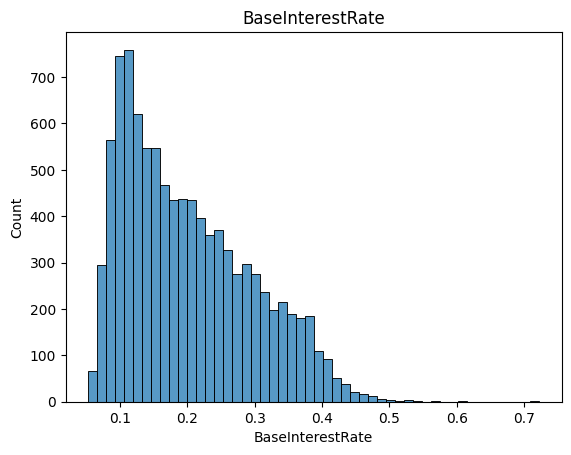

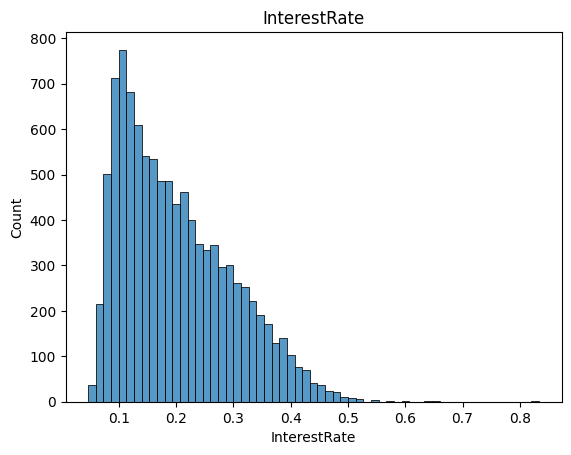

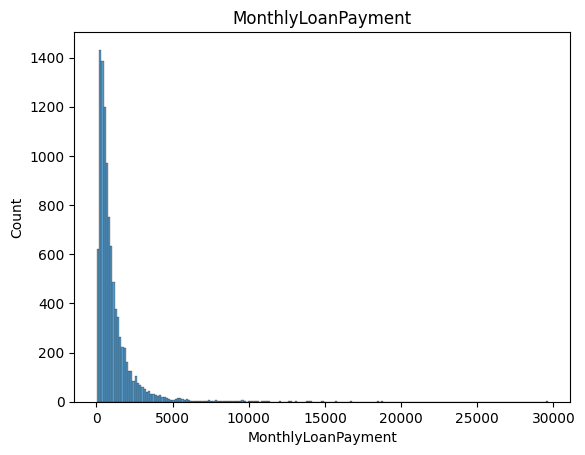

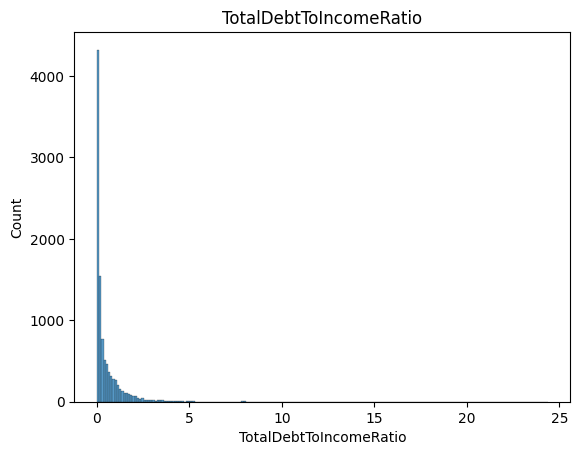

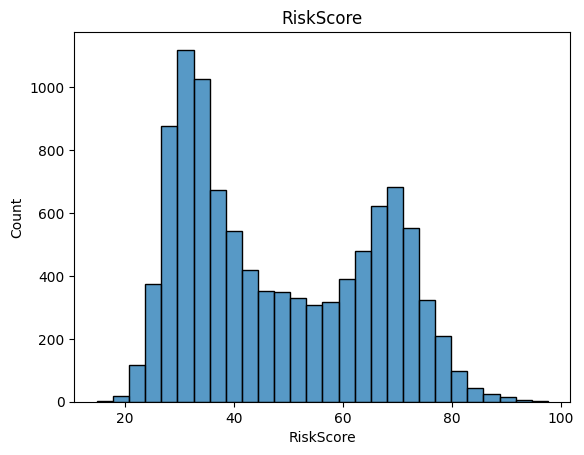

In [4]:
for col in df.select_dtypes(include=[np.number]).columns:
    sns.histplot(df[col])
    plt.title(col)
    plt.show()

<Axes: >

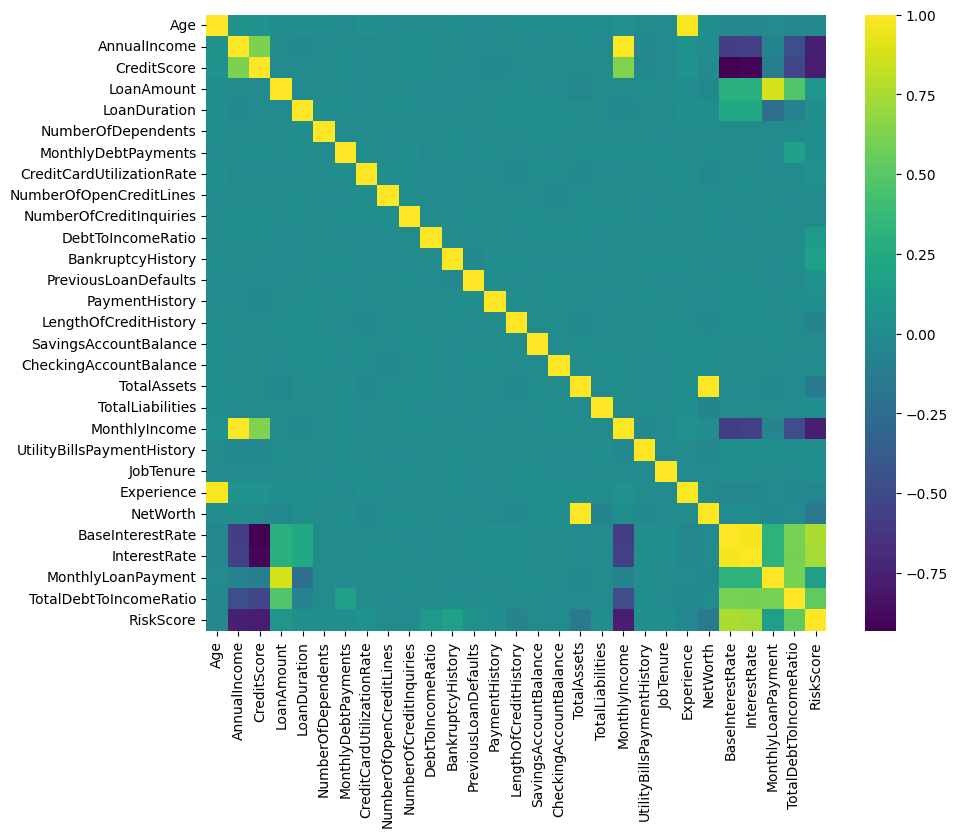

In [5]:
numerical_data = df[df.select_dtypes(include=np.number).columns]
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_data.corr(), annot=False, cmap="viridis")

зависимости есть. Надо будет убрать

проверяем min max и z-score

In [6]:
dfNum = df.select_dtypes(include=np.number)

def z_score_scaler(data):
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    return (data - mean) / (std)


def min_max_scaler(data):
    min_val = np.min(data, axis=0)
    max_val = np.max(data, axis=0)
    return (data - min_val) / (max_val - min_val)

dfNum.apply(z_score_scaler).describe()

,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,RiskScore
count,1.027200e+04,1.027200e+04,9.787000e+03,9.787000e+03,1.027200e+04,1.027200e+04,9.787000e+03,1.027200e+04,1.027200e+04,1.027200e+04,1.027200e+04,9.787000e+03,1.027200e+04,1.027200e+04,1.027200e+04,1.027200e+04,9.787000e+03,9.787000e+03,1.027200e+04,1.027200e+04,1.027200e+04,1.027200e+04,1.027200e+04,9.787000e+03,9.787000e+03,1.027200e+04,1.027200e+04,1.027200e+04,1.027200e+04
mean,1.556387e-16,-4.150366e-17,-2.773346e-16,-3.702634e-17,-1.051426e-16,-1.175937e-17,-3.121829e-17,6.467654e-17,-4.167660e-17,1.798492e-17,1.172479e-16,2.904027e-17,-5.343597e-17,-4.427058e-17,4.012021e-17,2.740971e-17,2.613624e-17,-1.089010e-17,1.936838e-17,-9.130806e-17,-4.288712e-17,-1.867665e-16,4.063900e-17,3.339631e-17,-2.947587e-16,1.798492e-16,-8.162387e-17,5.533822e-18,1.424959e-16
std,1.000049e+00,1.000049e+00,1.000051e+00,1.000051e+00,1.000049e+00,1.000049e+00,1.000051e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000051e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000051e+00,1.000051e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000051e+00,1.000051e+00,1.000049e+00,1.000049e+00,1.000049e+00,1.000049e+00
min,-1.884053e+00,-1.006139e+00,-2.154997e+00,-1.037780e+00,-1.689394e+00,-1.105987e+00,-1.061412e+00,-1.762081e+00,-1.742302e+00,-9.892814e-01,-1.709755e+00,-2.356768e-01,-3.276795e-01,-3.299619e+00,-1.684619e+00,-6.461840e-01,-6.436362e-01,-3.890128e-01,-3.365609e-01,-1.021052e+00,-4.270349e+00,-2.248149e+00,-1.556883e+00,-3.307928e-01,-1.565307e+00,-1.591903e+00,-7.758036e-01,-5.704440e-01,-1.944053e+00
25%,-6.775611e-01,-9.552763e-01,-7.294009e-01,-6.209365e-01,-7.106318e-01,-1.105987e+00,-6.236651e-01,-7.869498e-01,-5.919291e-01,-9.892814e-01,-7.749099e-01,-2.356768e-01,-3.276795e-01,-6.198852e-01,-8.784074e-01,-4.846737e-01,-4.752187e-01,-3.414468e-01,-2.981523e-01,-9.755967e-01,-6.167601e-01,-8.862665e-01,-7.625108e-01,-3.172485e-01,-8.528343e-01,-8.350617e-01,-5.198101e-01,-5.027124e-01,-9.068898e-01
50%,1.186290e-02,-3.672745e-01,2.514096e-01,-2.908562e-01,-2.212506e-01,-4.005725e-01,-2.953553e-01,-1.395909e-01,-1.674267e-02,2.225538e-02,-1.520028e-01,-2.356768e-01,-3.276795e-01,-1.484995e-03,4.297685e-02,-2.984520e-01,-2.839539e-01,-2.615456e-01,-2.264112e-01,-3.692158e-01,1.573595e-01,2.165506e-02,-5.640208e-02,-2.739170e-01,-1.949116e-01,-2.005267e-01,-2.906295e-01,-3.783998e-01,-2.414242e-01
75%,7.012869e-01,1.085218e+00,9.813150e-01,2.647969e-01,2.681306e-01,1.010256e+00,2.727201e-01,6.701175e-01,5.584437e-01,1.033792e+00,6.256053e-01,-2.356768e-01,-3.276795e-01,6.169152e-01,8.491881e-01,8.856398e-02,1.008604e-01,-4.541386e-02,-4.603594e-02,1.109620e+00,7.685846e-01,4.756158e-01,7.379702e-01,-6.422354e-02,6.831575e-01,6.709301e-01,1.501288e-01,1.330595e-01,9.724766e-01
max,3.458983e+00,5.326928e+00,9.813150e-01,1.398965e+01,2.715037e+00,3.126498e+00,2.055928e+01,3.952541e+00,5.159935e+00,5.079939e+00,4.260246e+00,4.243098e+00,3.051762e+00,4.121183e+00,1.655399e+00,2.566428e+01,3.500767e+01,2.380676e+01,4.365185e+01,1.508799e+00,1.723073e+00,5.469184e+00,3.474142e+00,2.407496e+01,5.520533e+00,6.558751e+00,2.112389e+01,2.656313e+01,2.855997e+00


In [7]:
dfNum.apply(min_max_scaler).describe()

,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,RiskScore
count,10272.000000,10272.000000,9787.000000,9787.000000,10272.000000,10272.000000,9787.000000,10272.000000,10272.000000,10272.000000,10272.000000,9787.000000,10272.000000,10272.000000,10272.000000,10272.000000,9787.000000,9787.000000,10272.000000,10272.000000,10272.000000,10272.000000,10272.000000,9787.000000,9787.000000,10272.000000,10272.000000,10272.000000,10272.000000
mean,0.352618,0.158871,0.687112,0.069059,0.383567,0.261309,0.049092,0.308346,0.252426,0.163000,0.286391,0.052621,0.096963,0.444645,0.504374,0.024560,0.018054,0.016078,0.007651,0.403602,0.712506,0.291312,0.309456,0.013554,0.220906,0.195310,0.035425,0.021024,0.405007
std,0.187169,0.157909,0.318862,0.066548,0.227055,0.236279,0.046254,0.174998,0.144888,0.164774,0.167512,0.223287,0.295921,0.134763,0.299414,0.038010,0.028051,0.041332,0.022734,0.395299,0.166858,0.129585,0.198776,0.040976,0.141134,0.122696,0.045665,0.036857,0.208341
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.225806,0.008031,0.454545,0.027739,0.222222,0.000000,0.020247,0.170638,0.166667,0.000000,0.156590,0.000000,0.000000,0.361111,0.241379,0.006139,0.004724,0.001966,0.000873,0.017968,0.609600,0.176471,0.157895,0.000555,0.100549,0.092856,0.011689,0.002496,0.216073
50%,0.354839,0.100878,0.767273,0.049704,0.333333,0.166667,0.035432,0.283919,0.250000,0.166667,0.260930,0.000000,0.000000,0.444444,0.517241,0.013216,0.010089,0.005268,0.002504,0.257658,0.738761,0.294118,0.298246,0.002330,0.193399,0.170707,0.022154,0.007078,0.354711
75%,0.483871,0.330228,1.000000,0.086680,0.444444,0.500000,0.061706,0.425610,0.333333,0.333333,0.391183,0.000000,0.000000,0.527778,0.758621,0.027926,0.020883,0.014201,0.006605,0.842212,0.840744,0.352941,0.456140,0.010922,0.317318,0.277626,0.042281,0.025927,0.607604
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
def preprocess(X_in: pd.DataFrame) -> pd.DataFrame:
    X = X_in.copy()
    categorical = X.select_dtypes(include=["object"]).columns
    numerical = X.select_dtypes(include=[np.number]).columns

    for col in numerical:
        if X[col].isnull().sum() == 0:
            continue
        median_val = X[col].median()
        X[col].fillna(median_val, inplace=True)

    for col in categorical:
        if X[col].isnull().sum() == 0:
            continue
        mode_val = X[col].mode()[0]
        X[col].fillna(mode_val, inplace=True)


    X["LoanToIncomeRatio"] = X["LoanAmount"] / (X["AnnualIncome"] + 1)
    X["DebtToAssetsRatio"] = X["TotalLiabilities"] / (X["TotalAssets"] + 1)
    X["SavingsToLoanRatio"] = X["SavingsAccountBalance"] / (X["LoanAmount"] + 1)
    X["CreditHistoryInteraction"] = X["LengthOfCreditHistory"] * X["PaymentHistory"]

    clip_cols = ["MonthlyIncome","LoanAmount","AnnualIncome","SavingsAccountBalance","TotalAssets","TotalLiabilities","MonthlyDebtPayments"]
    for col in clip_cols:
        lo = X[col].quantile(0.01)
        hi = X[col].quantile(0.99)
        X[col] = X[col].clip(lo, hi)
    log_candidates = ["MonthlyIncome","LoanAmount","SavingsAccountBalance","CheckingAccountBalance","TotalAssets","TotalLiabilities","NetWorth","MonthlyDebtPayments"]
    for col in log_candidates:
        X[col] = np.log1p(X[col])

    return X


y = df["RiskScore"]
X = df.drop(columns=["RiskScore"])

X_eng = preprocess(X)
X_eng.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanToIncomeRatio,DebtToAssetsRatio,SavingsToLoanRatio,CreditHistoryInteraction
0,2010-06-26,27.0,66829.0,549.0,9.757941,60.0,Divorced,1.0,Rent,6.999422,0.151985,2.0,1.0,0.168542,0.0,Education,0.0,23.0,5.0,7.839919,5.513429,10.821237,9.616205,8.625165,0.908289,4.0,Employed,Associate,4.0,10.465044,0.257790,0.251465,508.970230,0.288013,0.258716,0.299662,0.146839,115.0
1,1996-09-23,55.0,172147.0,850.0,9.687258,36.0,Widowed,1.0,Mortgage,5.356586,0.175693,3.0,0.0,0.141553,0.0,Home,0.0,27.0,11.0,6.739337,6.543912,11.428228,11.080264,9.571267,0.797339,2.0,Employed,High School,33.0,10.203666,0.086110,0.093173,514.675859,0.050585,0.093582,0.706113,0.052387,297.0
2,2015-01-19,51.0,300000.0,850.0,10.556776,36.0,Married,0.0,Mortgage,6.304449,0.444605,3.0,0.0,0.030987,1.0,Education,0.0,21.0,12.0,9.453835,6.480045,12.585539,9.541010,10.126671,0.915945,3.0,Employed,Bachelor,28.0,12.536753,0.108436,0.115443,1268.276385,0.072571,0.128120,0.047615,0.331868,252.0
3,1981-05-12,25.0,34683.0,847.0,9.861988,48.0,Married,0.0,Other,5.036953,0.188452,7.0,0.0,0.379843,0.0,Debt Consolidation,0.0,27.0,21.0,7.329750,6.272877,9.478151,8.255049,7.969444,0.876416,3.0,Employed,High School,0.0,9.129672,0.100686,0.112822,498.505187,0.225415,0.553166,0.294239,0.079429,567.0
4,1995-05-07,55.0,300000.0,850.0,10.323447,48.0,Single,2.0,Rent,6.333280,0.273431,3.0,1.0,0.068659,0.0,Debt Consolidation,0.0,35.0,9.0,7.587817,4.859812,10.415053,12.770261,10.126671,0.888689,5.0,Employed,Bachelor,31.0,8.412499,0.110437,0.089037,756.035156,0.052721,0.101456,10.540290,0.064820,315.0


убираем зависимости

In [9]:
numericalX = X_eng.select_dtypes(include=[np.number]).copy()
corr = numericalX.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
X_eng.drop(columns=to_drop)
to_drop

['Experience', 'InterestRate']

In [10]:
binned = ["Age", "CreditScore"]
categorical = X.select_dtypes(include=["object"]).columns
numerical = [x for x in X.select_dtypes(include=[np.number]).columns if x not in binned]

numerical_transformer = Pipeline(steps=[
    ("scaler", RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True, drop="first"))
])

binned_transformer = Pipeline(steps=[
    ("bin", KBinsDiscretizer(n_bins=20, encode="onehot-dense", strategy="quantile"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical),
        ("cat", categorical_transformer, categorical),
        ("bin", binned_transformer, binned)
    ])


pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("var", VarianceThreshold(threshold=1e-5)),
    ("preselect", SelectKBest(score_func=f_regression, k=X_eng.shape[1])),
    ("poly", PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)),
    ("select", SelectKBest(score_func=f_regression, k=800)),
])
pipe

,steps,"[('preprocessor', ...), ('var', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [11]:
y_bins = pd.cut(y, bins=6, labels=False)
X_train, X_test, y_train, y_test = train_test_split(X_eng, y, test_size=0.3, random_state=42, stratify=y_bins)

X_train = pipe.fit_transform(X_train, y_train)
X_test   = pipe.transform(X_test)

на предыдущей 

alpha=28.31578947368421, w=0.6166562093103263, mse=27.044682632237002

alpha=27.846153846153847, w=0.6147406385774055, mse=27.044760042886168
alpha=27.692307692307693, w=0.6140767374162226, mse=27.0447425348076

In [12]:
# alpha_grid = np.linspace(0, 100, 20)
# alpha_grid = np.linspace(10, 100, 100)
# alpha_grid = np.linspace(20, 29, 40)
# alpha_grid = np.linspace(27, 28, 40)
alpha_grid = [27.692307692307693]

# alpha_grid = [28.205128205128204]
alpha_grid

best_mse = 2000
best_w = 1
best_alpha = 0

for i, alpha in enumerate(alpha_grid):
    rid = Ridge(alpha=float(alpha))
    rid.fit(X_train, y_train)

    lin = LinearRegression()
    lin.fit(X_train, y_train)

    lin_pred = lin.predict(X_test)
    rig_pred = rid.predict(X_test)

    weight = optimal_weight(y_test.values, lin_pred, rig_pred)
    diff = 0.05
    step = 0.001
    weights = np.clip(np.arange(weight - diff, weight + diff + step, step), 
                      0.0, 1.0)

    diff = None
    for w in weights:
        pred_mix = w * lin_pred + (1.0 - w) * rig_pred
        mse = mean_squared_error(y_test, pred_mix)
        if mse < best_mse:
            diff = best_mse - mse
            best_alpha = alpha
            best_mse = mse
            best_w = w

    diff = 0 if diff is None else diff
    print(f"alpha  = {alpha:.4f} [{i+1:2}/{len(alpha_grid)}]: {diff}")

print(f"alpha={best_alpha}, w={best_w}, mse={best_mse}")

alpha  = 27.6923 [ 1/1]: 1.8252968736476305e-06
alpha=27.692307692307693, w=0.6140767374162226, mse=27.0447425348076


решаем задачу

In [13]:
X_full = X_eng.copy()
X_out = pd.read_csv("./data/test.csv")
X_out = X_out.drop(columns="ID")
X_out = preprocess(X_out)

pipe_final = pipe
X_full = pipe_final.fit_transform(X_full, y)
X_out = pipe_final.transform(X_out)

lin = LinearRegression()
lin.fit(X_full, y)

rig = Ridge(alpha=best_alpha)
rig.fit(X_full, y)

lin_pred = lin.predict(X_out)
rig_pred = rig.predict(X_out)
mix_pred = best_w * lin_pred + (1.0 - best_w) * rig_pred

sub = pd.DataFrame({"ID": np.arange(len(mix_pred)), "RiskScore": mix_pred})
sub.to_csv("out.csv", index=False)
sub.sort_values(by="RiskScore")

,ID,RiskScore
2617,2617,11.423305
652,652,15.463563
995,995,16.016714
3728,3728,16.158614
874,874,16.516990
...,...,...
2432,2432,94.318641
2705,2705,94.330126
3059,3059,94.488880
1678,1678,96.797471


In [14]:
def calc_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def calc_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def calc_mape(y_true, y_pred, epsilon=1e-10):
    return np.mean(np.abs((y_true - y_pred) / y_true + epsilon)) 

def calc_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return 1.0 if ss_res == 0 else 0.0

    return 1 - (ss_res / ss_tot)


lin = LinearRegression()
lin.fit(X_train, y_train)
pred = lin.predict(X_test)
print(abs(mean_squared_error(y_test, pred) - calc_mse(y_test, pred)))
print(abs(mean_absolute_error(y_test, pred) - calc_mae(y_test, pred)))
print(abs(mean_absolute_percentage_error(y_test, pred) - calc_mape(y_test, pred)))
print(abs(r2_score(y_test, pred) - calc_r2(y_test, pred)))

0.0
0.0
8.436029652614252e-13
0.0


класс линейной регрессии

In [15]:
class Linear:
    def _fit_analyze(self, X, y):
        self.weights = np.linalg.inv(X.T @ X) @ X.T @ y

    def _fit_gradient(self, X, y, learning_rate, n_iterations):
        h, w = X.shape
        self.weights = np.random.randn(w) * 0.01
        for i in range(n_iterations):
            pred = X @ self.weights
            gradient = (2 / h) * X.T @ (pred - y)
            self.weights -= learning_rate * gradient
            if np.any(np.isnan(self.weights)) or np.any(np.isinf(self.weights)):
                raise RuntimeError(f"Warning: NaN/Inf detected at iteration {i}\n" +
                                    f"Gradient norm: {np.linalg.norm(gradient)}")

    def _fit_stoch(self, X, y, learning_rate, n_iterations):
        h, w = X.shape
        self.weights = np.random.randn(w) * 0.01
        for _ in range(n_iterations):
            indices = np.random.permutation(h)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            for i in range(h):
                xi = X[i:i+1]
                yi = y[i:i+1]
                pred = xi @ self.weights
                gradient = 2 * xi.T @ (pred - yi)
                self.weights -= learning_rate * gradient
                if np.any(np.isnan(self.weights)) or np.any(np.isinf(self.weights)):
                    raise RuntimeError(f"Warning: NaN/Inf detected at iteration {i}\n" +
                                        f"Gradient norm: {np.linalg.norm(gradient)}")


    def fit(self, X, y, method = 0, learning_rate = 0.01, n_iterations = 1000):
        if method == 0:
            return self._fit_analyze(X, y)
        if method == 1:
            return self._fit_gradient(X, y, learning_rate, n_iterations)
        if method == 2:
            return self._fit_stoch(X, y, learning_rate, n_iterations)
        raise RuntimeError(f"invalid method")

    def predict(self, X):
        if self.weights is None:
            raise RuntimeError(f"not taught")
        return X @ self.weights

проверяем работу класса

In [16]:
df2 = df.copy().select_dtypes(include=np.number).dropna()
df2 = df2.apply(z_score_scaler)
y2 = df2["RiskScore"]
X2 = df2.drop(columns=["RiskScore"])

X_train, X_test, y_train, y_test = train_test_split(X2.to_numpy(), y2.to_numpy(), test_size=0.33, random_state=42)

In [17]:
%%time
lin_sk = LinearRegression()
lin_sk.fit(X_train, y_train)
pred = lin_sk.predict(X_test)
calc_mse(y_test, pred)

CPU times: user 4.11 ms, sys: 1.65 ms, total: 5.77 ms
Wall time: 3.27 ms


np.float64(0.16969045372335817)

In [18]:
%%time
lin_an = Linear()
lin_an.fit(X_train, y_train, 0)
pred = lin_an.predict(X_test)
calc_mse(y_test, pred)

CPU times: user 676 μs, sys: 739 μs, total: 1.42 ms
Wall time: 565 μs


np.float64(0.16968555213526634)

In [19]:
%%time
lin_gr = Linear()
lin_gr.fit(X_train, y_train, 1, n_iterations=10000)
pred = lin_gr.predict(X_test)
calc_mse(y_test, pred)

CPU times: user 1.5 s, sys: 605 ms, total: 2.11 s
Wall time: 1.26 s


np.float64(0.1697577137786844)

In [85]:
%%time
lin_sgr = Linear()
lin_sgr.fit(X_train, y_train, 2, n_iterations=1000)
pred = lin_sgr.predict(X_test)
calc_mse(y_test, pred)

CPU times: user 41.2 s, sys: 416 ms, total: 41.6 s
Wall time: 42 s


np.float64(0.49762931154826945)

In [84]:
res = pd.DataFrame()
res["fields"] = X2.columns
res["sklearn"] = lin_sk.coef_
res["analytical"] = lin_an.weights
res["gradient"] = lin_gr.weights
res["stoch"] = lin_sgr.weights
res

,fields,sklearn,analytical,gradient,stoch
0,Age,0.004934,3.915999e+09,0.005269,-0.047460
1,AnnualIncome,-0.004866,-1.750994e+10,-0.022540,0.208157
2,CreditScore,-0.222739,-1.560409e+12,-0.222277,-0.402592
3,LoanAmount,0.034692,4.805671e+11,0.034783,0.210970
4,LoanDuration,-0.052326,3.439065e+11,-0.052549,-0.113362
5,NumberOfDependents,0.008793,3.770155e-03,0.008835,-0.146078
6,MonthlyDebtPayments,0.021864,1.885992e-02,0.021780,0.120019
7,CreditCardUtilizationRate,0.046392,4.668906e-02,0.046448,0.097135
8,NumberOfOpenCreditLines,-0.002527,2.325291e-04,-0.002575,-0.071132
9,NumberOfCreditInquiries,-0.004292,-4.483323e-03,-0.004200,-0.073203


аналитическая и sklearn совпадают. Спуски немного отличаются

In [53]:
def k_fold(model, X, y, k=5):
    permutation = np.random.permutation(X.shape[0])
    splits = np.array_split(permutation, k)
    scores = []
    for i in range(k):
        test_idx = splits[i]
        train_idx = np.concatenate([splits[j] for j in range(k) if j != i])
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        scores.append(calc_mse(y_test, pred))
    return scores

def leave_one_out(model, X, y):
    scores = []
    for i in range(X.shape[0]):
        X_test, y_test = X[i:i+1], y[i:i+1]
        X_train = np.concatenate([X[:i], X[i+1:]])
        y_train = np.concatenate([y[:i], y[i+1:]])
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        scores.append(calc_mse(y_test, pred))
    return scores

In [23]:
lin_an = Linear()
k_fold(lin_an, X2.to_numpy(), y2.to_numpy())

[np.float64(0.17014352045144646),
 np.float64(0.18656678696105364),
 np.float64(0.16712383241603743),
 np.float64(0.16844983612211734),
 np.float64(0.17538652692603243)]

In [54]:
lin_an = Linear()
mse = leave_one_out(lin_an, X2.to_numpy(), y2.to_numpy())
print("calculated")

calculated


In [76]:
resmse = pd.DataFrame({"mse": mse})
resmse.describe()

,mse
count,9.787000e+03
mean,1.189297e+20
std,1.129518e+21
min,6.981061e-09
25%,2.804566e-02
50%,1.272748e-01
75%,3.789530e-01
max,3.425618e+22


при leave_one_out выявляются сильные отклонений

In [82]:
resmse2 = resmse[(resmse["mse"] < resmse["mse"].quantile(0.9)) &
        (resmse["mse"] > resmse["mse"].quantile(0.1))
]
resmse2.describe()

,mse
count,7829.000000
mean,0.205047
std,0.210645
min,0.004332
25%,0.041561
50%,0.127275
75%,0.302106
max,0.926720
